In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from timeit import default_timer as timer

from tensorflow.keras.utils import to_categorical # type: ignore
from tensorflow.keras.models import Sequential # type: ignore
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D, Rescaling, AvgPool2D, BatchNormalization, Reshape # type: ignore
from tensorflow.keras.preprocessing.image import ImageDataGenerator # type: ignore
from tensorflow.keras.callbacks import EarlyStopping, LearningRateScheduler # type: ignore

dataset = "/mnt/d/datasets/spanish_traffic/Classification/"

labelfile = pd.read_csv(dataset + "gt_spanish_dataset.csv")

2025-09-12 15:38:00.162323: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
labelfile.head()

,image,width,height,class_id,class_name
0,Image00001.jpg,174,174,1,R-1
1,Image00002.jpg,240,240,1,R-1
2,Image00003.jpg,320,320,1,R-1
3,Image00004.jpg,120,120,1,R-1
4,Image00005.jpg,86,86,1,R-1


In [43]:
import tensorflow as tf

# Parameters
img_size = (128, 128)
batch_size = 32
validation_split = 0.3
seed = 42

# Load training dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset,
    validation_split=validation_split,
    subset="training",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size
)

# Load validation / test dataset
test_ds = tf.keras.utils.image_dataset_from_directory(
    dataset,
    validation_split=validation_split,
    subset="validation",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size
)

# Optional: Normalize images
normalization_layer = tf.keras.layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

print("Classes:", train_ds)


Found 1478 files belonging to 99 classes.
Using 1035 files for training.
Found 1478 files belonging to 99 classes.
Using 443 files for validation.
Classes: <_MapDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


In [ ]:
import matplotlib.pyplot as plt
import tensorflow as tf

# Reload the dataset without .map() to preserve class_names
img_size = (128, 128)
batch_size = 32
validation_split = 0.3
seed = 42

train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    dataset,
    validation_split=validation_split,
    subset="training",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size
)

# Get class names before mapping
class_names = train_ds_raw.class_names
num_classes = len(class_names)

# Apply normalization afterwards
normalization_layer = tf.keras.layers.Rescaling(1./255)
train_ds = train_ds_raw.map(lambda x, y: (normalization_layer(x), y))

# Dictionary to keep track of one image per class
seen_classes = {}

# Loop over batches
for images, labels in train_ds:
    for img, label in zip(images, labels):
        label_int = label.numpy()
        if label_int not in seen_classes:
            seen_classes[label_int] = img.numpy()
        if len(seen_classes) == num_classes:
            break
    if len(seen_classes) == num_classes:
        break

# Plot one image per class
cols = 10
rows = (num_classes + cols - 1) // cols
plt.figure(figsize=(cols*2, rows*2))
for i, (label_int, img) in enumerate(seen_classes.items()):
    ax = plt.subplot(rows, cols, i+1)
    plt.imshow(img)
    plt.title(class_names[label_int])
    plt.axis("off")
plt.tight_layout()
plt.show()


AttributeError: '_MapDataset' object has no attribute 'class_names'

In [44]:
import tensorflow as tf
from tensorflow.keras import layers, models # type: ignore
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint # type: ignore

# Number of classes
num_classes = 99  # Make sure this matches your dataset

model = models.Sequential([
    layers.InputLayer(input_shape=(128, 128, 3)),
    layers.Rescaling(1./255),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

# Compile the model
model.compile(
    optimizer='adam',
    loss="sparse_categorical_crossentropy",
    metrics=['accuracy']
)

# Callbacks for early stopping and saving best model
checkpoint = ModelCheckpoint('model.keras', monitor='val_accuracy', save_best_only=True)

# Train the model
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=50,  # Train longer, early stopping will prevent overfitting
    callbacks=[checkpoint]
)

# Evaluate best model on test set
best_model = tf.keras.models.load_model('model.keras')
test_loss, test_acc = best_model.evaluate(test_ds)
print(f"Test accuracy: {test_acc:.4f}")



Epoch 1/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.0763 - loss: 4.2206

2025-09-13 00:46:37.198139: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-09-13 00:46:38.254118: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_100', 8 bytes spill stores, 8 bytes spill loads

2025-09-13 00:46:38.532613: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_100', 84 bytes spill stores, 84 bytes spill loads



33/33 ━━━━━━━━━━━━━━━━━━━━ 11s 235ms/step - accuracy: 0.0770 - loss: 4.2141 - val_accuracy: 0.1084 - val_loss: 3.8685
Epoch 2/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.0928 - loss: 3.7164 - val_accuracy: 0.1084 - val_loss: 3.7797
Epoch 3/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.1159 - loss: 3.5819 - val_accuracy: 0.1084 - val_loss: 3.7957
Epoch 4/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.1119 - loss: 3.5739 - val_accuracy: 0.1084 - val_loss: 3.8076
Epoch 5/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.0882 - loss: 3.5911 - val_accuracy: 0.1084 - val_loss: 3.7792
Epoch 6/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.0923 - loss: 3.5751 - val_accuracy: 0.1084 - val_loss: 3.7914
Epoch 7/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.1004 - loss: 3.6004 - val_accuracy: 0.1084 - val_loss: 3.8094
Epoch 8/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.0994 - loss: 3.5327 - val_accuracy: 0.1084 - val_loss: 

2025-09-13 00:51:45.785493: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


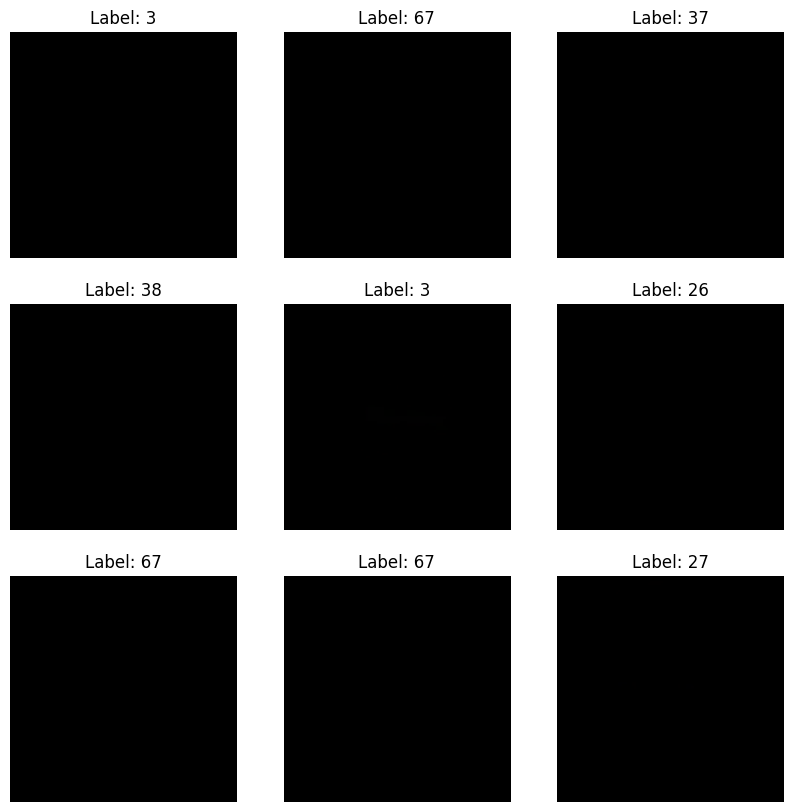

In [45]:
import matplotlib.pyplot as plt

# Display first 9 images and their labels from train_ds
plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):  # take 1 batch
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))  # rescaled images are floats 0-1
        plt.title(f"Label: {labels[i].numpy()}")
        plt.axis("off")
